# Example analysis
We'll be looking at a CSV dataset of people who tip at restaurants. The source data can be found in `data/tips.csv`.

The original dataset can be found at https://github.com/mwaskom/seaborn-data.

Tipping behavior at a popular US restaurant chain in a mall in 1990.

## Import pandas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb

## Import the dataset

In [2]:
df = pd.read_csv('data/tips.csv')

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,female,No,Sun,Dinner,4


In [4]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
# (number of rows, number of columns)
df.shape

(244, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [7]:
# summarize total number of null values per column
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Describe the data

In [8]:
# stats about the dataset
# Total number of rows (excluding headers), mean, standard deviation, min, 25, 50 and 75 percentiles, max
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
# mean total_bill
df['total_bill'].mean() 

np.float64(19.78594262295082)

In [10]:
# mean tip
df['tip'].mean()

np.float64(2.99827868852459)

In [11]:
# mean tip per total_bill in percentage
np.round(df['tip'].mean() / df['total_bill'].mean() * 100, 2)

np.float64(15.15)

In [12]:
# another way to get mean tip per total_bill in percentage
np.round(df.tip.mean() / df.total_bill.mean()*100, 2)

np.float64(15.15)

## Clean some data

In [13]:
# number of instances of distinct values in sex column
df.sex.value_counts()

sex
Male      150
Female     84
male        3
M           3
female      2
m           1
F           1
Name: count, dtype: int64

In [14]:
# apply str.title() method to all values of the sex column.
df.sex.str.title()

# permanently change df sex column
df.sex = df.sex.str.title()

# In the sex column, find all values that start with "F" and make them "Female"
df.loc[df.sex.str.startswith("F"), "sex"] = "Female"

df.loc[df.sex.str.startswith("M"), "sex"] = "Male"


### Clean smoker column

In [15]:
df.smoker.value_counts()

smoker
No     138
Yes     90
no       7
N        5
Y        2
yes      1
n        1
Name: count, dtype: int64

In [16]:
df.loc[df.smoker.str.startswith("Y"), "smoker"] = "Yes"
df.loc[df.smoker.str.startswith("y"), "smoker"] = "Yes"
df.loc[df.smoker.str.startswith("N"), "smoker"] = "No"
df.loc[df.smoker.str.startswith("n"), "smoker"] = "No"


In [17]:
# access by attribute name
df.day.value_counts()
# access by attribute key
# df["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [18]:
df.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

## Add new columns

### Add percent column

In [19]:
# add a percent column, save it using attribute key
df['percent'] = df.tip / df.total_bill * 100
df['percent'] = df.percent.round(2)
df.head()

,total_bill,tip,sex,smoker,day,time,size,percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


### Add bill_per_person column

In [20]:
df['bill_per_person'] = df.total_bill / df['size']
df['bill_per_person'] = df.bill_per_person.round(2)
df.head()

,total_bill,tip,sex,smoker,day,time,size,percent,bill_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94,8.49
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05,3.45
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66,7.00
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98,11.84
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68,6.15


## Plot some data

<Axes: xlabel='total_bill', ylabel='tip'>

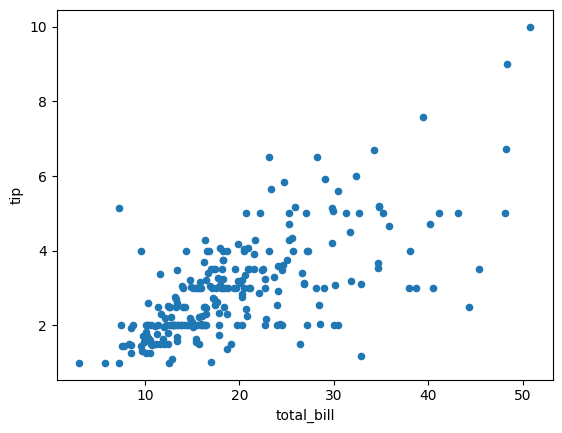

In [21]:
df.plot.scatter(x='total_bill', y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

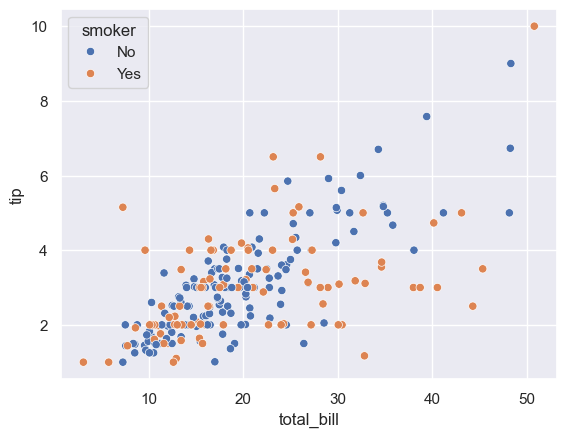

In [24]:
# set default seaborn theme
sb.set_theme()
sb.scatterplot(x='total_bill',y='tip',hue='smoker',data=df)

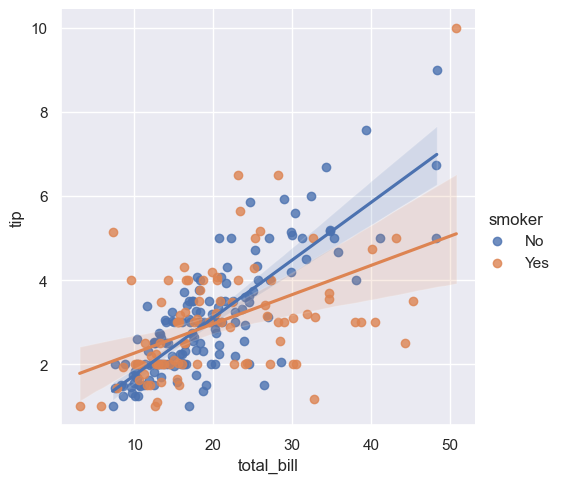

In [25]:
# apply linear regression model, including uncertainty
sb.lmplot(x='total_bill',y='tip',hue='smoker',data=df)
# conclusion of linear regression model: non-smoking customers typically tip higher than smoking customers, if the total_bill is higher.

<Axes: xlabel='day', ylabel='count'>

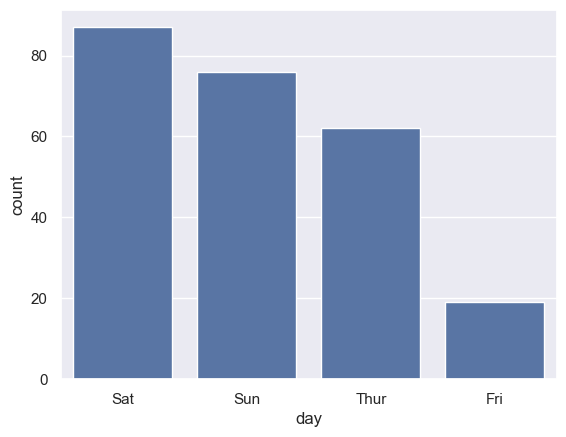

In [26]:
# plot how many days of different instances
sb.barplot(data=df.day.value_counts())

<Axes: xlabel='sex', ylabel='count'>

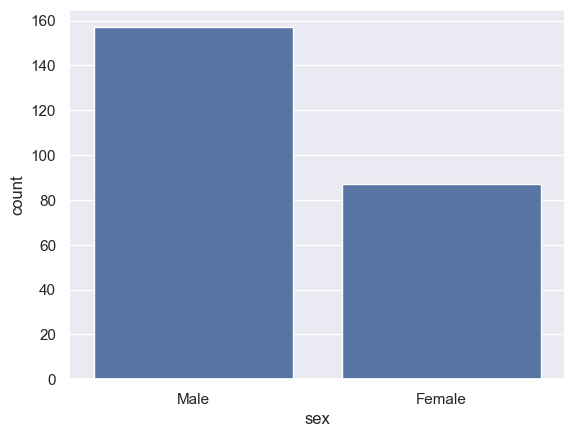

In [27]:
sb.barplot(data=df.sex.value_counts())

<Axes: xlabel='time', ylabel='count'>

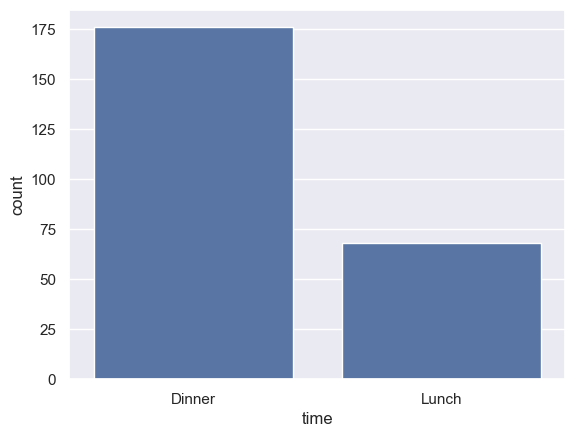

In [28]:
sb.barplot(data=df.time.value_counts())

<Axes: xlabel='smoker', ylabel='count'>

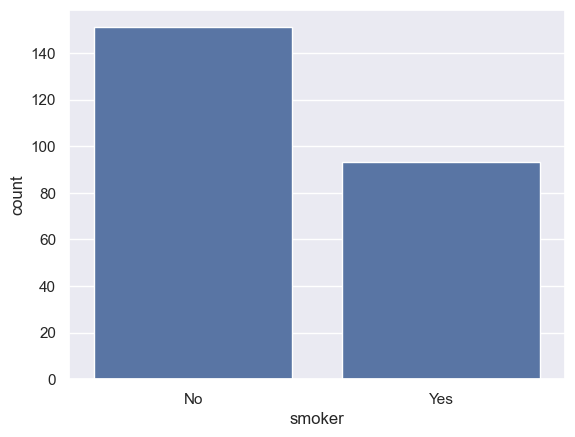

In [30]:
sb.barplot(data=df.smoker.value_counts())

<Axes: xlabel='day', ylabel='percent'>

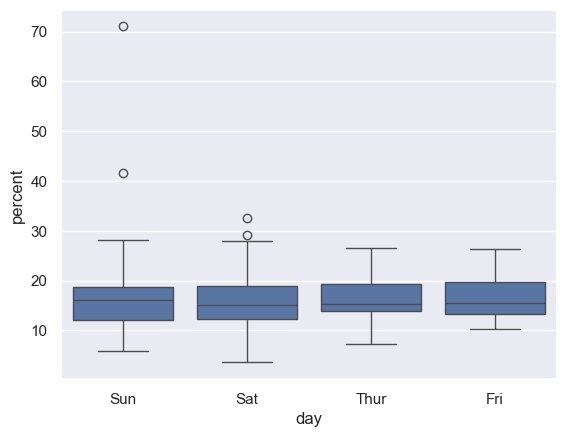

In [32]:
sb.boxplot(x='day',y='percent',data=df)

<Axes: xlabel='day', ylabel='percent'>

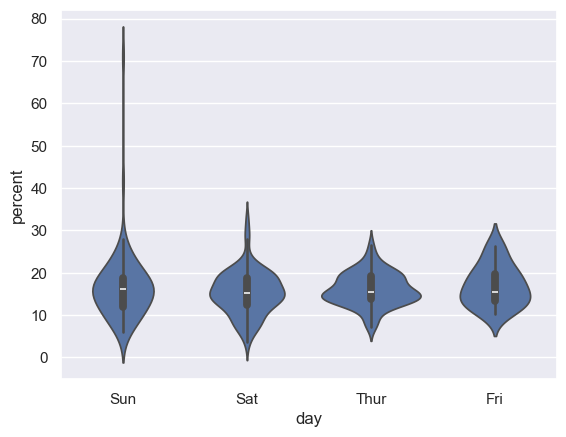

In [33]:
sb.violinplot(x='day',y='percent',data=df)

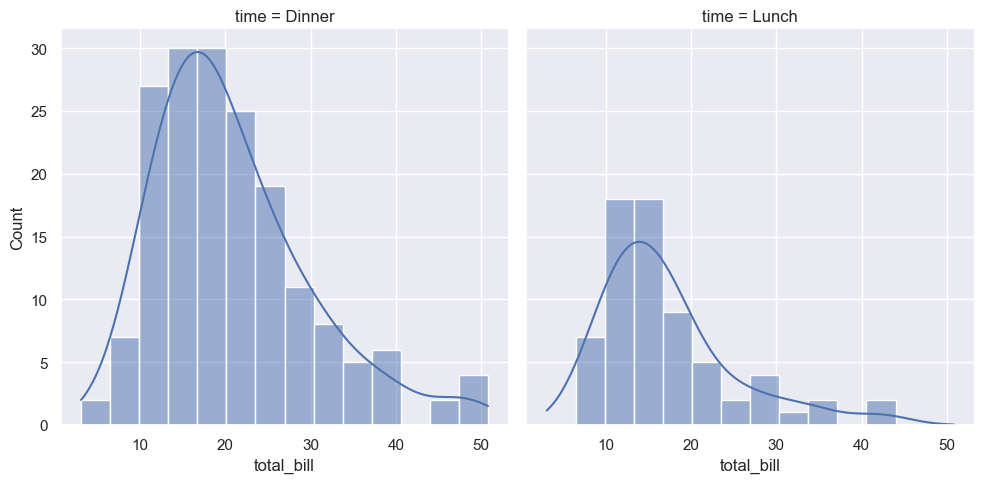

In [34]:
# distributional representations (kde = kernel density estimation)
sb.displot(x='total_bill',col='time',data=df,kde=True)

<Axes: xlabel='tip', ylabel='percent'>

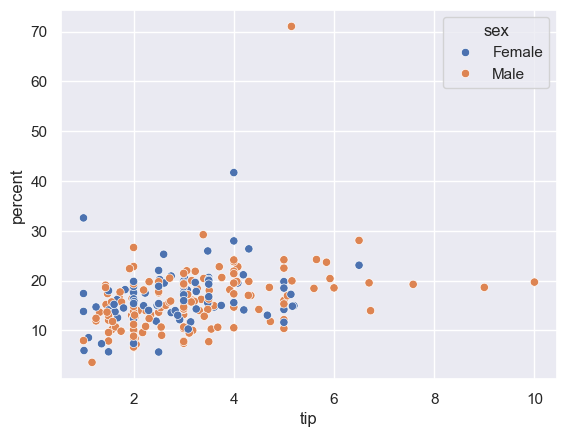

In [35]:
sb.scatterplot(x='tip',y='percent',hue='sex',data=df)

## 
Get some statistsics

In [37]:
df.groupby('day').describe()

total_bill                                                             \
          count       mean       std   min      25%    50%      75%    max   
day                                                                          
Fri        19.0  17.151579  8.302660  5.75  12.0950  15.38  21.7500  40.17   
Sat        87.0  20.441379  9.480419  3.07  13.9050  18.24  24.7400  50.81   
Sun        76.0  21.410000  8.832122  7.25  14.9875  19.63  25.5975  48.17   
Thur       62.0  17.682742  7.886170  7.51  12.4425  16.20  20.1550  43.11   

       tip            ...  percent        bill_per_person                      \
     count      mean  ...      75%    max           count      mean       std   
day                   ...                                                       
Fri   19.0  2.734737  ...  19.6650  26.35            19.0  8.133158  3.053501   
Sat   87.0  2.993103  ...  18.8250  32.57            87.0  8.186782  2.917818   
Sun   76.0  3.255132  ...  18.7850  71.03            76.0  7.863684  3.212442   
Thur  62.0  2.771452  ...  19.2675  26.63            62.0  7.424194  2.454378   

                                          
       min    25%    50%      75%    max  
day                                       
Fri   2.88  6.050  7.690  10.2700  14.48  
Sat   3.07  5.800  7.530  10.0700  16.94  
Sun   3.44  5.925  7.315   8.7375  20.27  
Thur  3.76  5.750  6.780   8.6925  16.34  

[4 rows x 40 columns]

In [44]:
# get a new dataframe with only 2 columns: day and percent
df[['day','percent']]

,day,percent
0,Sun,5.94
1,Sun,16.05
2,Sun,16.66
3,Sun,13.98
4,Sun,14.68
...,...,...
239,Sat,20.39
240,Sat,7.36
241,Sat,8.82
242,Sat,9.82


In [45]:
# which day of the week a server earn what percent tip
df[['day','percent']].groupby('day').describe()

percent                                                            
       count       mean       std    min      25%    50%      75%    max
day                                                                     
Fri     19.0  16.991579  4.766803  10.36  13.3750  15.56  19.6650  26.35
Sat     87.0  15.314598  5.129187   3.56  12.3850  15.18  18.8250  32.57
Sun     76.0  16.689605  8.473462   5.94  12.0000  16.11  18.7850  71.03
Thur    62.0  16.126452  3.864958   7.30  13.8175  15.38  19.2675  26.63

In [46]:
# tip amount at dinner or lunch time
df[['time','tip']].groupby('time').describe()

tip                                                   
        count      mean       std   min  25%   50%     75%   max
time                                                            
Dinner  176.0  3.102670  1.436243  1.00  2.0  3.00  3.6875  10.0
Lunch    68.0  2.728088  1.205345  1.25  2.0  2.25  3.2875   6.7

In [47]:
# total_bill at dinner or lunch time
df[['total_bill','time']].groupby('time').describe()

total_bill                                                            
            count       mean       std   min      25%     50%      75%    max
time                                                                         
Dinner      176.0  20.797159  9.142029  3.07  14.4375  18.390  25.2825  50.81
Lunch        68.0  17.168676  7.713882  7.51  12.2350  15.965  19.5325  43.11

In [50]:
# mean of all total_bill at dinner or lunch time
df[['total_bill','time']].groupby('time').mean()

,total_bill
time,
Dinner,20.797159
Lunch,17.168676


In [55]:
# mean of all total_bill at dinner time only
df[['total_bill','time']].groupby('time').mean().loc['Dinner']

total_bill    20.797159
Name: Dinner, dtype: float64